In [ ]:

!pip -q install pandas openpyxl scipy scikit-learn matplotlib seaborn mlxtend

In [ ]:

from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_excel(file_name)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Saving simulated_weather.xlsx to simulated_weather.xlsx
Dataset loaded successfully!
Rows: 1000
Columns: 11


,Date,Temperature_C,Humidity_percent,Pressure_hPa,WindSpeed_kmh,WindDirection_deg,Rainfall_mm,CloudCover_percent,SolarRadiation_Wm2,Visibility_km,DewPoint_C
0,2020-01-01,26.662276,73.465667,1005.905440,2.460962,174.606475,3.777383,58.571364,442.339292,8.828793,22.998681
1,2020-01-02,24.929423,71.528897,1010.538071,7.698075,30.745091,0.000000,56.993476,398.703892,8.796958,19.057846
2,2020-01-03,27.459262,63.450003,1006.970640,9.931972,350.086100,0.000000,16.343202,472.639758,8.179771,20.342728
3,2020-01-04,30.257114,56.265751,1012.283157,21.438438,186.483755,13.468111,47.212145,429.216695,7.327616,20.542292
4,2020-01-05,25.157188,69.761813,996.898720,14.782766,221.107048,0.000000,12.228642,771.690936,10.681088,18.597769


In [ ]:

print("DATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

print("\nNUMERICAL SUMMARY")
display(df.describe().T)

DATASET SHAPE
(1000, 11)

COLUMN NAMES
['Date', 'Temperature_C', 'Humidity_percent', 'Pressure_hPa', 'WindSpeed_kmh', 'WindDirection_deg', 'Rainfall_mm', 'CloudCover_percent', 'SolarRadiation_Wm2', 'Visibility_km', 'DewPoint_C']

DATA TYPES
Date                  datetime64[ns]
Temperature_C                float64
Humidity_percent             float64
Pressure_hPa                 float64
WindSpeed_kmh                float64
WindDirection_deg            float64
Rainfall_mm                  float64
CloudCover_percent           float64
SolarRadiation_Wm2           float64
Visibility_km                float64
DewPoint_C                   float64
dtype: object

MISSING VALUES


,0
Date,0
Temperature_C,0
Humidity_percent,0
Pressure_hPa,0
WindSpeed_kmh,0
WindDirection_deg,0
Rainfall_mm,0
CloudCover_percent,0
SolarRadiation_Wm2,0
Visibility_km,0



DUPLICATE ROWS
0

NUMERICAL SUMMARY


,count,mean,min,25%,50%,75%,max,std
Date,1000,2021-05-14 12:00:00,2020-01-01 00:00:00,2020-09-06 18:00:00,2021-05-14 12:00:00,2022-01-19 06:00:00,2022-09-26 00:00:00,NaN
Temperature_C,1000.0,25.681532,5.446932,19.390812,26.00587,32.024965,43.543882,7.618365
Humidity_percent,1000.0,64.950628,37.872349,58.397904,65.254835,71.678756,94.382291,9.305337
Pressure_hPa,1000.0,1013.056548,986.831548,1007.48732,1012.977071,1018.226665,1045.714038,8.067207
WindSpeed_kmh,1000.0,11.927138,0.048478,8.312898,12.000923,15.334727,28.215465,5.087276
WindDirection_deg,1000.0,179.694941,2.226176,88.46192,176.930602,271.372885,359.766108,104.457786
Rainfall_mm,1000.0,1.452341,0.0,0.0,0.0,0.0,33.792011,4.1476
CloudCover_percent,1000.0,42.413806,0.0,30.987496,42.600026,53.385842,89.395276,16.274164
SolarRadiation_Wm2,1000.0,488.529978,130.271328,410.04976,489.516453,566.706019,847.513926,117.496112
Visibility_km,1000.0,9.773983,3.412929,8.412968,9.726287,11.121222,16.165531,2.100111


In [ ]:

import numpy as np

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:
    pearson_corr = numeric_df.corr(method="pearson")
    spearman_corr = numeric_df.corr(method="spearman")

    display(pearson_corr)
    display(spearman_corr)

    pairs = []
    columns = numeric_df.columns.tolist()

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            pairs.append({
                "Feature 1": columns[i],
                "Feature 2": columns[j],
                "Pearson": pearson_corr.iloc[i, j],
                "Spearman": spearman_corr.iloc[i, j]
            })

    corr_results = pd.DataFrame(pairs)

    if not corr_results.empty:
        corr_results["Absolute Pearson"] = (
            corr_results["Pearson"].abs()
        )
        display(
            corr_results.sort_values(
                "Absolute Pearson", ascending=False
            )
        )
else:
    print("At least two numeric columns are needed.")

,Temperature_C,Humidity_percent,Pressure_hPa,WindSpeed_kmh,WindDirection_deg,Rainfall_mm,CloudCover_percent,SolarRadiation_Wm2,Visibility_km,DewPoint_C
Temperature_C,1.000000,-0.661079,0.125585,-0.079726,-0.020684,-0.024143,-0.217355,0.144697,0.265683,0.965313
Humidity_percent,-0.661079,1.000000,-0.221257,0.010333,0.044901,0.100547,0.319207,-0.230449,-0.360895,-0.477818
Pressure_hPa,0.125585,-0.221257,1.000000,0.019758,0.001536,-0.021345,-0.054860,0.031213,0.101643,0.085359
WindSpeed_kmh,-0.079726,0.010333,0.019758,1.000000,0.018223,-0.060752,-0.018279,-0.006627,-0.056732,-0.097276
WindDirection_deg,-0.020684,0.044901,0.001536,0.018223,1.000000,-0.007727,-0.031965,0.030681,0.007346,-0.015774
Rainfall_mm,-0.024143,0.100547,-0.021345,-0.060752,-0.007727,1.000000,0.072630,-0.058851,-0.075444,0.000205
CloudCover_percent,-0.217355,0.319207,-0.054860,-0.018279,-0.031965,0.072630,1.000000,-0.733651,-0.157609,-0.159188
SolarRadiation_Wm2,0.144697,-0.230449,0.031213,-0.006627,0.030681,-0.058851,-0.733651,1.000000,0.102825,0.101815
Visibility_km,0.265683,-0.360895,0.101643,-0.056732,0.007346,-0.075444,-0.157609,0.102825,1.000000,0.195928
DewPoint_C,0.965313,-0.477818,0.085359,-0.097276,-0.015774,0.000205,-0.159188,0.101815,0.195928,1.000000


,Temperature_C,Humidity_percent,Pressure_hPa,WindSpeed_kmh,WindDirection_deg,Rainfall_mm,CloudCover_percent,SolarRadiation_Wm2,Visibility_km,DewPoint_C
Temperature_C,1.000000,-0.659762,0.117546,-0.078953,-0.017378,-0.041259,-0.212965,0.134272,0.266281,0.965547
Humidity_percent,-0.659762,1.000000,-0.218222,0.013289,0.044664,0.127178,0.301506,-0.216408,-0.350006,-0.486556
Pressure_hPa,0.117546,-0.218222,1.000000,0.021901,0.006101,-0.026321,-0.055827,0.041029,0.091091,0.081228
WindSpeed_kmh,-0.078953,0.013289,0.021901,1.000000,0.014227,-0.092624,-0.018591,-0.007617,-0.069758,-0.094939
WindDirection_deg,-0.017378,0.044664,0.006101,0.014227,1.000000,-0.006060,-0.029612,0.038343,0.024265,-0.010931
Rainfall_mm,-0.041259,0.127178,-0.026321,-0.092624,-0.006060,1.000000,0.072622,-0.062308,-0.093616,-0.007979
CloudCover_percent,-0.212965,0.301506,-0.055827,-0.018591,-0.029612,0.072622,1.000000,-0.730373,-0.150191,-0.155759
SolarRadiation_Wm2,0.134272,-0.216408,0.041029,-0.007617,0.038343,-0.062308,-0.730373,1.000000,0.104320,0.090490
Visibility_km,0.266281,-0.350006,0.091091,-0.069758,0.024265,-0.093616,-0.150191,0.104320,1.000000,0.200626
DewPoint_C,0.965547,-0.486556,0.081228,-0.094939,-0.010931,-0.007979,-0.155759,0.090490,0.200626,1.000000


,Feature 1,Feature 2,Pearson,Spearman,Absolute Pearson
8,Temperature_C,DewPoint_C,0.965313,0.965547,0.965313
39,CloudCover_percent,SolarRadiation_Wm2,-0.733651,-0.730373,0.733651
0,Temperature_C,Humidity_percent,-0.661079,-0.659762,0.661079
16,Humidity_percent,DewPoint_C,-0.477818,-0.486556,0.477818
15,Humidity_percent,Visibility_km,-0.360895,-0.350006,0.360895
13,Humidity_percent,CloudCover_percent,0.319207,0.301506,0.319207
7,Temperature_C,Visibility_km,0.265683,0.266281,0.265683
14,Humidity_percent,SolarRadiation_Wm2,-0.230449,-0.216408,0.230449
9,Humidity_percent,Pressure_hPa,-0.221257,-0.218222,0.221257
5,Temperature_C,CloudCover_percent,-0.217355,-0.212965,0.217355


In [ ]:

from sklearn.feature_selection import mutual_info_regression

mi_results = []

if numeric_df.shape[1] >= 2:
    for target in numeric_df.columns:
        predictors = numeric_df.drop(columns=[target])
        clean = pd.concat(
            [predictors, numeric_df[target].rename("__target__")],
            axis=1
        ).dropna()

        if len(clean) < 10:
            continue

        X = clean[predictors.columns]
        y = clean["__target__"]

        if y.nunique() < 2:
            continue

        mi = mutual_info_regression(
            X, y, random_state=42
        )

        for feature, score in zip(X.columns, mi):
            mi_results.append({
                "Feature": feature,
                "Target": target,
                "Mutual Information": score
            })

mi_df = pd.DataFrame(mi_results)

if not mi_df.empty:
    display(
        mi_df.sort_values(
            "Mutual Information", ascending=False
        )
    )
else:
    print("Not enough suitable numerical data.")

,Feature,Target,Mutual Information
8,DewPoint_C,Temperature_C,1.280405
81,Temperature_C,DewPoint_C,1.280405
60,SolarRadiation_Wm2,CloudCover_percent,0.425029
69,CloudCover_percent,SolarRadiation_Wm2,0.425029
0,Humidity_percent,Temperature_C,0.263173
...,...,...,...
76,WindDirection_deg,Visibility_km,0.000000
79,SolarRadiation_Wm2,Visibility_km,0.000000
74,Pressure_hPa,Visibility_km,0.000000
85,WindDirection_deg,DewPoint_C,0.000000


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_data = numeric_df.replace(
    [np.inf, -np.inf], np.nan
).dropna()

if len(cluster_data) >= 3 and cluster_data.shape[1] >= 2:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_data)

    k = min(3, len(cluster_data) - 1)

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    cluster_results = cluster_data.copy()
    cluster_results["Cluster"] = cluster_labels

    display(cluster_results.head(10))
    display(cluster_results.groupby("Cluster").mean())
else:
    print("Insufficient complete numerical data for clustering.")

,Temperature_C,Humidity_percent,Pressure_hPa,WindSpeed_kmh,WindDirection_deg,Rainfall_mm,CloudCover_percent,SolarRadiation_Wm2,Visibility_km,DewPoint_C,Cluster
0,26.662276,73.465667,1005.905440,2.460962,174.606475,3.777383,58.571364,442.339292,8.828793,22.998681,1
1,24.929423,71.528897,1010.538071,7.698075,30.745091,0.000000,56.993476,398.703892,8.796958,19.057846,1
2,27.459262,63.450003,1006.970640,9.931972,350.086100,0.000000,16.343202,472.639758,8.179771,20.342728,0
3,30.257114,56.265751,1012.283157,21.438438,186.483755,13.468111,47.212145,429.216695,7.327616,20.542292,2
4,25.157188,69.761813,996.898720,14.782766,221.107048,0.000000,12.228642,771.690936,10.681088,18.597769,0
5,25.328606,67.491513,1014.208047,5.322592,85.179522,0.000000,40.356176,466.196620,10.639200,20.394587,0
6,30.939719,66.514577,1012.706728,14.430181,174.059311,0.000000,18.325473,461.529692,8.451095,24.991117,0
7,28.675092,66.506129,1006.162065,4.263480,154.493817,0.000000,53.399228,498.161197,10.437277,22.394862,0
8,25.134665,72.239137,1016.826138,17.413455,26.962503,0.000000,48.382530,383.886533,8.887977,17.644518,1
9,28.340612,58.580864,1021.784388,9.644377,38.217727,0.000000,27.586708,579.220777,12.525874,19.340312,0


,Temperature_C,Humidity_percent,Pressure_hPa,WindSpeed_kmh,WindDirection_deg,Rainfall_mm,CloudCover_percent,SolarRadiation_Wm2,Visibility_km,DewPoint_C
Cluster,,,,,,,,,,
0,31.381831,59.438962,1014.246987,11.629036,178.075651,0.561981,37.292370,515.618005,10.471968,23.279322
1,18.640755,71.350998,1011.590105,12.442795,181.960392,0.722306,48.003725,459.596745,8.986885,12.853645
2,25.998028,67.911613,1013.091063,10.728170,177.477064,16.075599,48.030292,453.750245,9.211126,19.516050


In [ ]:

from sklearn.ensemble import IsolationForest

if len(cluster_data) >= 10 and cluster_data.shape[1] >= 1:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_data)

    detector = IsolationForest(
        contamination="auto",
        random_state=42
    )

    labels = detector.fit_predict(X_scaled)

    anomaly_results = cluster_data.copy()
    anomaly_results["Anomaly"] = labels == -1

    display(
        anomaly_results[
            anomaly_results["Anomaly"]
        ].head(20)
    )

    print(
        "Potential anomalies:",
        int((labels == -1).sum())
    )
else:
    print("Insufficient data for anomaly detection.")

,Temperature_C,Humidity_percent,Pressure_hPa,WindSpeed_kmh,WindDirection_deg,Rainfall_mm,CloudCover_percent,SolarRadiation_Wm2,Visibility_km,DewPoint_C,Anomaly
3,30.257114,56.265751,1012.283157,21.438438,186.483755,13.468111,47.212145,429.216695,7.327616,20.542292,True
17,28.991954,58.419236,998.285254,2.160778,42.915759,4.896560,17.691634,753.125090,10.030829,19.070347,True
24,27.538788,75.061772,986.831548,2.651292,303.837650,5.145294,60.772655,385.707824,9.376323,23.850731,True
33,27.351220,67.649395,1016.513882,7.088530,38.384503,11.024852,77.717387,207.734661,6.245674,18.942708,True
35,27.145472,74.301530,1033.216974,14.234362,35.818081,7.935631,57.073722,302.832621,9.105253,20.662277,True
54,36.208389,52.181153,1004.796802,20.674683,196.706547,0.000000,0.424216,784.522971,9.299626,24.674723,True
66,33.925250,48.797030,996.730057,20.774665,245.921143,0.000000,45.846274,474.486922,13.826810,25.527972,True
73,39.256279,44.614031,1018.655719,20.159284,316.741589,0.000000,22.654110,565.696874,9.212340,28.785237,True
81,35.944832,53.799330,1020.049788,12.701799,273.744024,20.100384,36.617293,579.248542,11.597999,25.612420,True
82,39.333007,51.282149,1004.192732,2.164651,243.503413,0.000000,0.605850,749.718028,13.842689,29.983530,True


Potential anomalies: 116


In [ ]:

from mlxtend.frequent_patterns import (
    apriori, association_rules
)

categorical_df = df.select_dtypes(
    include=["object", "category", "bool"]
).copy()

# Convert each value to a categorical item
# while preserving which column it came from.
transactions = pd.DataFrame(index=df.index)

for col in categorical_df.columns:
    values = categorical_df[col].astype("string")
    transactions[col] = (
        col + "=" + values.fillna("MISSING")
    )

if transactions.shape[1] >= 2 and len(transactions) >= 2:
    encoded = pd.get_dummies(transactions)

    frequent_items = apriori(
        encoded.astype(bool),
        min_support=0.05,
        use_colnames=True,
        max_len=3
    )

    if not frequent_items.empty:
        rules = association_rules(
            frequent_items,
            metric="confidence",
            min_threshold=0.5
        )

        if not rules.empty:
            display(
                rules.sort_values(
                    "lift", ascending=False
                ).head(20)
            )
        else:
            print("No rules met the confidence threshold.")
    else:
        print("No frequent itemsets met minimum support.")
else:
    print("At least two categorical columns are recommended.")

At least two categorical columns are recommended.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Date,Temperature_C
0,2020-01-01,26.662276
1,2020-01-02,24.929423
2,2020-01-03,27.459262
3,2020-01-04,30.257114
4,2020-01-05,25.157188


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Date,Humidity_percent
0,2020-01-01,73.465667
1,2020-01-02,71.528897
2,2020-01-03,63.450003
3,2020-01-04,56.265751
4,2020-01-05,69.761813


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Date,Visibility_km
0,2020-01-01,8.828793
1,2020-01-02,8.796958
2,2020-01-03,8.179771
3,2020-01-04,7.327616
4,2020-01-05,10.681088


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Date,DewPoint_C
0,2020-01-01,22.998681
1,2020-01-02,19.057846
2,2020-01-03,20.342728
3,2020-01-04,20.542292
4,2020-01-05,18.597769


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

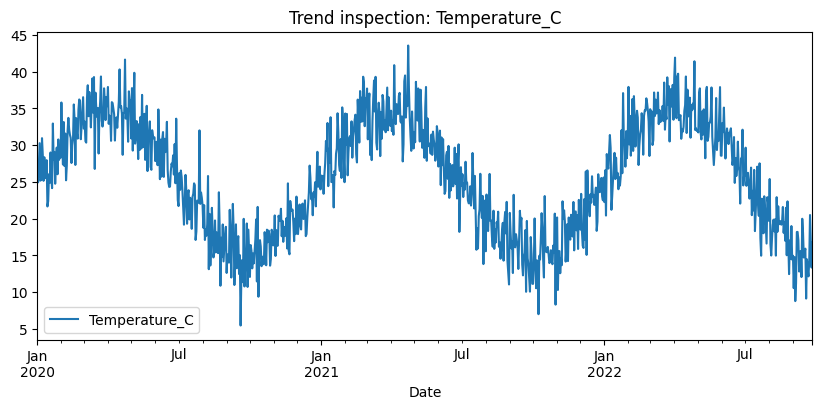

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

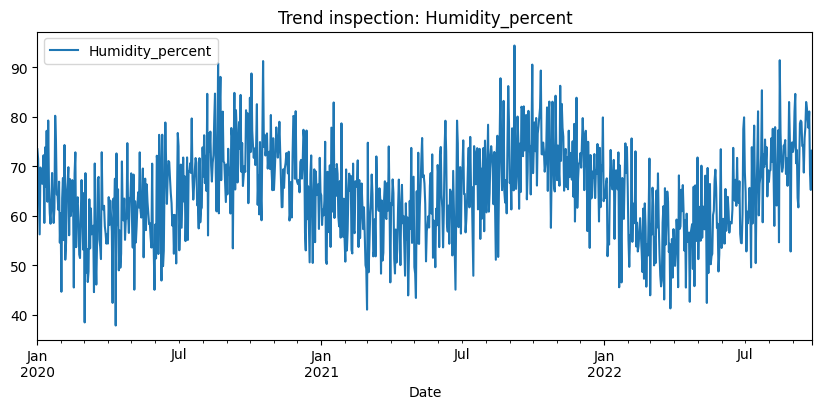

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

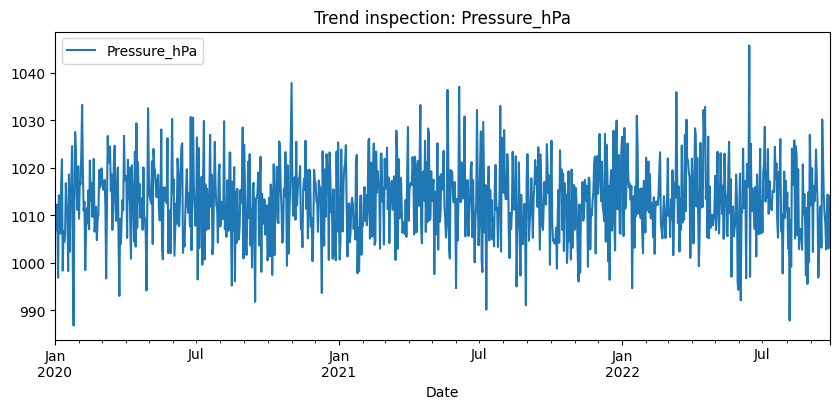

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

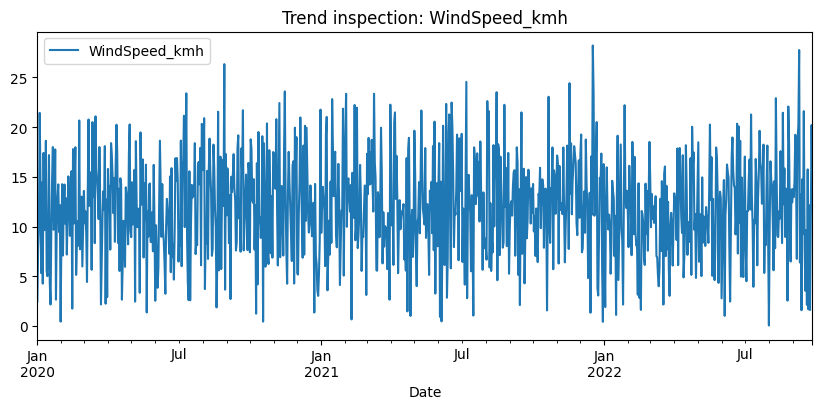

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

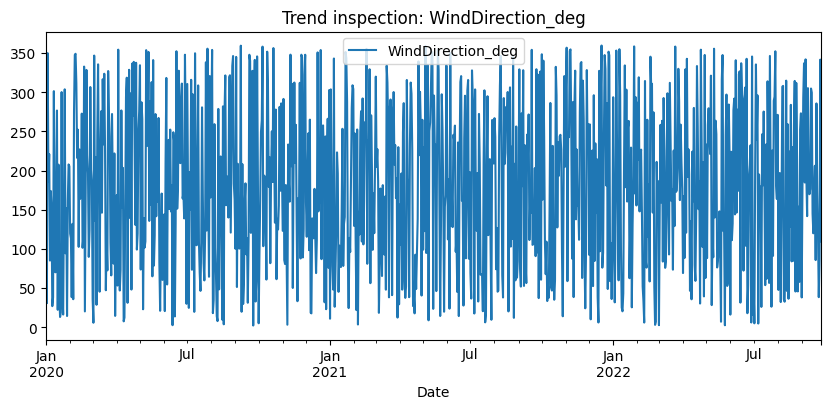

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

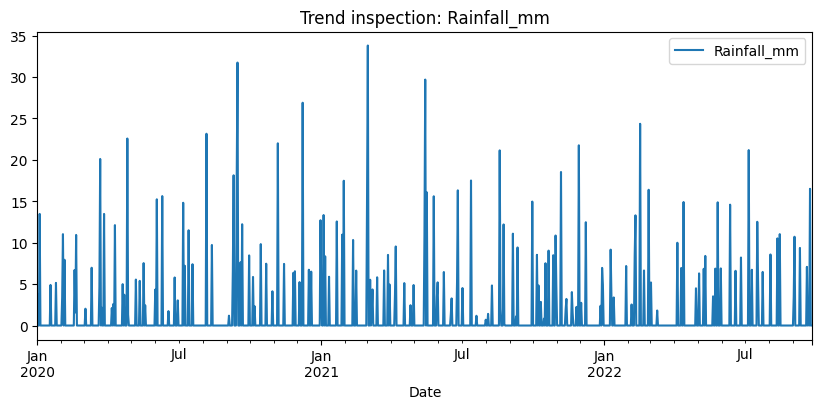

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

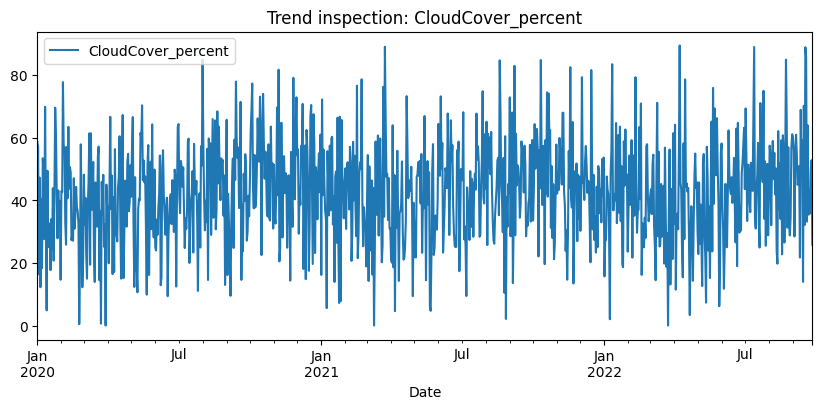

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

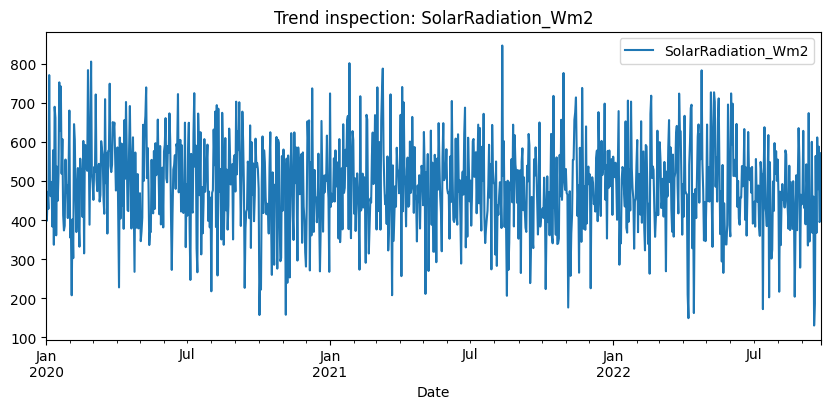

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

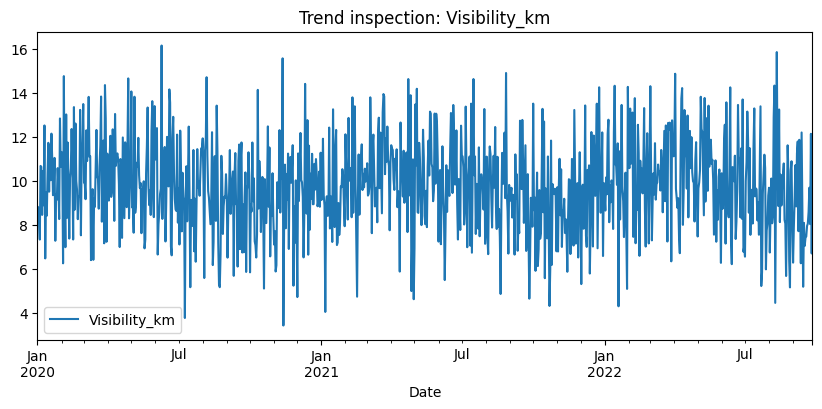

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

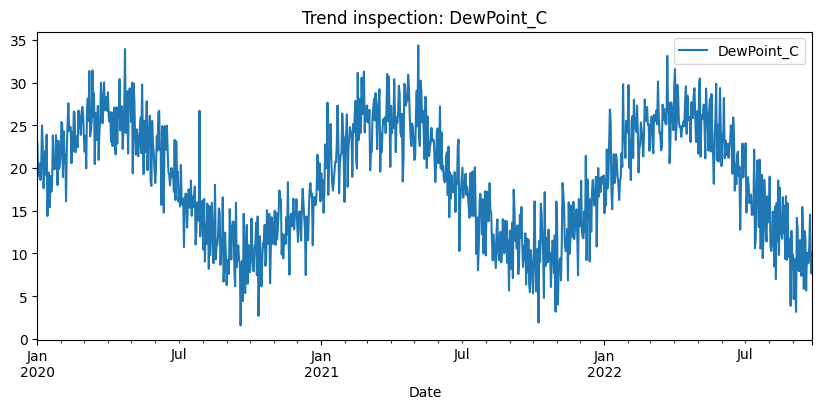

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:

date_column = "Date"  # Change this to your date column

if date_column in df.columns:
    trend_df = df.copy()
    trend_df[date_column] = pd.to_datetime(
        trend_df[date_column], errors="coerce"
    )

    trend_df = trend_df.dropna(subset=[date_column])
    trend_df = trend_df.sort_values(date_column)

    trend_columns = trend_df.select_dtypes(
        include=np.number
    ).columns

    if len(trend_df) >= 3:
        for col in trend_columns:
            display(
                trend_df[[date_column, col]].head()
            )

            trend_df.plot(
                x=date_column, y=col,
                figsize=(10, 4),
                title=f"Trend inspection: {col}"
            )
else:
    print(
        "No configured date column found. "
        "Configure a date or sequence column if available."
    )

In [ ]:

import statsmodels.formula.api as smf

# Change these to actual numeric column names.
target = "Efficiency"
feature_a = "Temperature"
feature_b = "Load"

required = [target, feature_a, feature_b]

if all(col in df.columns for col in required):
    interaction_data = df[required].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()

    if len(interaction_data) >= 20:
        formula = (
            f'Q("{target}") ~ Q("{feature_a}")'
            f' * Q("{feature_b}")'
        )

        model = smf.ols(
            formula, data=interaction_data
        ).fit()

        print(model.summary())
    else:
        print("Not enough complete observations.")
else:
    print("Update target and feature names first.")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Update target and feature names first.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
!pip -q install statsmodels

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

In [ ]:

from datetime import datetime

report_lines = [
    "# Pattern Mining Agent Report",
    "",
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    "",
    "## 1. Dataset Overview",
    f"- Rows: {df.shape[0]}",
    f"- Columns: {df.shape[1]}",
    f"- Duplicate rows: {int(df.duplicated().sum())}",
    f"- Missing cells: {int(df.isna().sum().sum())}",
    "",
    "## 2. Correlation Findings",
]

if "corr_results" in globals() and not corr_results.empty:
    top_pairs = corr_results.sort_values(
        "Absolute Pearson", ascending=False
    ).head(10)

    for _, row in top_pairs.iterrows():
        report_lines.append(
            f"- {row['Feature 1']} and {row['Feature 2']}: "
            f"Pearson r={row['Pearson']:.3f}; "
            f"Spearman rho={row['Spearman']:.3f}."
        )
else:
    report_lines.append("- Correlation analysis unavailable.")

report_lines.extend([
    "",
    "## 3. Interpretation Notes",
    "- Correlation does not establish causation.",
    "- Review sample size, missingness and data quality.",
    "- Investigate findings with suitable statistical tests.",
    "- Treat candidate hypotheses as provisional."
])

report_text = "\n".join(report_lines)

with open("pattern_mining_report.md", "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# Pattern Mining Agent Report

Generated: 2026-10-03 06:31

## 1. Dataset Overview
- Rows: 1000
- Columns: 11
- Duplicate rows: 0
- Missing cells: 0

## 2. Correlation Findings
- Temperature_C and DewPoint_C: Pearson r=0.965; Spearman rho=0.966.
- CloudCover_percent and SolarRadiation_Wm2: Pearson r=-0.734; Spearman rho=-0.730.
- Temperature_C and Humidity_percent: Pearson r=-0.661; Spearman rho=-0.660.
- Humidity_percent and DewPoint_C: Pearson r=-0.478; Spearman rho=-0.487.
- Humidity_percent and Visibility_km: Pearson r=-0.361; Spearman rho=-0.350.
- Humidity_percent and CloudCover_percent: Pearson r=0.319; Spearman rho=0.302.
- Temperature_C and Visibility_km: Pearson r=0.266; Spearman rho=0.266.
- Humidity_percent and SolarRadiation_Wm2: Pearson r=-0.230; Spearman rho=-0.216.
- Humidity_percent and Pressure_hPa: Pearson r=-0.221; Spearman rho=-0.218.
- Temperature_C and CloudCover_percent: Pearson r=-0.217; Spearman rho=-0.213.

## 3. Interpretation Notes
- Correlation does not es

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [1]:
!pip install crewai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/4